# AVD on the Hydraulic dataset — paper replication

This notebook reproduces the AVD-based classification pipeline from [main.py](main.py) on the **Hydraulic** dataset, using the parameters reported in the paper:

- `dataset` = `"Hydraulic"`
- `w_size` = `10`
- `w_incre` = `1`
- `metric` ∈ {`MAD`, `SD`}

The pipeline is the one summarised in the [README](README.md): load and normalise the multivariate cycles, compute the AVD feature per cycle, reshape into a per-cycle table, and benchmark with `LazyClassifier`. A few plots are added along the way to help interpret each step.

## Imports

In [9]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lazypredict.Supervised import LazyClassifier

from AVD_function import calculate_AVD_feature

## Paper parameters

These are the values used for the Hydraulic experiments in the paper.

In [10]:
dataset = "Hydraulic"
w_size = 10
w_incre = 1

## 1. Load and prepare the data

Read the aggregated CSV and set `(cycle, time)` as a MultiIndex so each cycle is one full multivariate sample.

In [11]:
data = pd.read_csv(f'data/{dataset}_aggregated_data.csv')

# rescale `time` from 100 ms units to integer indices (matches `main.py`)
data['time'] = (data['time'] / 100).astype(int)

data.set_index(['cycle', 'time'], inplace=True)
data.head()

CE     CP    EPS1    FS1     FS2     PS1      PS2    PS3  \
cycle time                                                                 
0     0     47.202  2.184  2411.6  8.990  10.179  151.47  125.500  2.305   
      1     47.273  2.184  2936.6  0.001  10.176  191.46    0.430  0.000   
      2     47.250  2.184  2656.2  0.005  10.163  179.09    0.133  0.000   
      3     47.332  2.185  2949.4  0.000  10.167  191.43    0.000  0.000   
      4     47.213  2.178  2945.8  0.000  10.167  191.36    0.000  0.000   

              PS5    PS6      SE     TS1     TS2     TS3     TS4    VS1  class  
cycle time                                                                      
0     0     9.936  9.818  68.039  35.570  40.961  38.320  30.363  0.604     18  
      1     9.974  9.846   0.000  35.492  40.949  38.332  30.375  0.605     18  
      2     9.984  9.865   0.000  35.469  40.965  38.320  30.367  0.611     18  
      3     9.947  9.823   0.000  35.422  40.922  38.324  30.367  0.603     18  
      4     9.964  9.847   0.000  35.414  40.879  38.332  30.379  0.608     18

### Class distribution

How many cycles are there per class? Strongly imbalanced classes can dominate the classification benchmark.

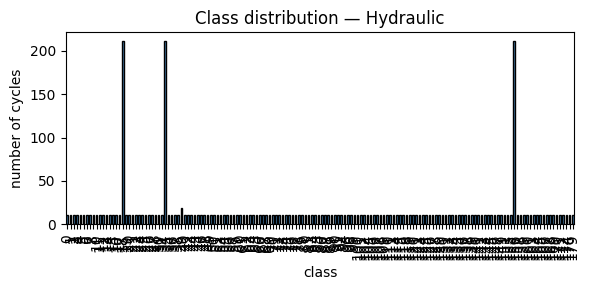

class
0      10
1      10
2      10
3      10
4      10
       ..
171    10
172    10
174    10
176    11
179    10
Name: count, Length: 156, dtype: int64

In [12]:
class_counts = (
    data.reset_index()
    .drop_duplicates(subset='cycle')['class']
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 3))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('class')
ax.set_ylabel('number of cycles')
ax.set_title(f'Class distribution — {dataset}')
plt.tight_layout()
plt.show()
class_counts

### Raw signals for one example cycle

A quick look at what one multivariate sample looks like before any processing.

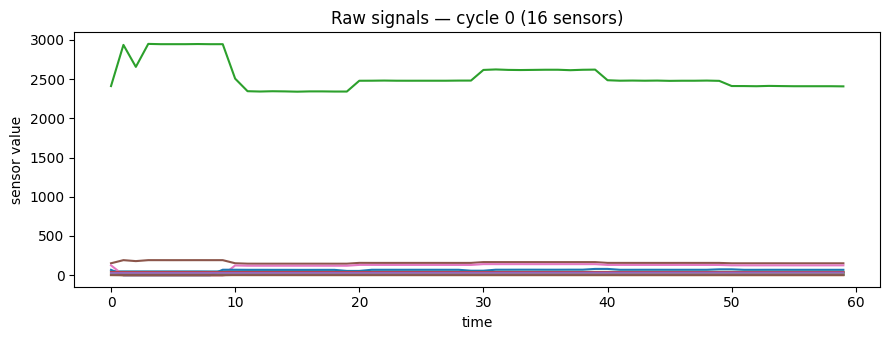

In [13]:
example_cycle = data.index.get_level_values('cycle').unique()[0]
example_raw = data.loc[example_cycle].drop(columns='class', errors='ignore')

fig, ax = plt.subplots(figsize=(9, 3.5))
example_raw.plot(ax=ax, legend=(example_raw.shape[1] <= 10))
ax.set_xlabel('time')
ax.set_ylabel('sensor value')
ax.set_title(f'Raw signals — cycle {example_cycle} ({example_raw.shape[1]} sensors)')
plt.tight_layout()
plt.show()

## 2. Mean-normalise each cycle

Subtract the per-cycle mean from every sensor column. The class label is constant within a cycle, so we keep a separate `class_info_series` and drop the column from the working frame.

In [14]:
sensor_columns = [col for col in data.columns if col != 'class']
print('Sensor columns:', sensor_columns)

mean_per_cycle = data.groupby(level='cycle')[sensor_columns].transform('mean')
normalized_cycles_data = data.copy()
normalized_cycles_data[sensor_columns] = data[sensor_columns] - mean_per_cycle

class_info_series = (
    normalized_cycles_data.reset_index()
    .drop_duplicates(subset='cycle')
    .set_index('cycle')['class']
)
normalized_cycles_data.drop(columns=['class'], inplace=True)
normalized_cycles_data.head()

Sensor columns: ['CE', 'CP', 'EPS1', 'FS1', 'FS2', 'PS1', 'PS2', 'PS3', 'PS5', 'PS6', 'SE', 'TS1', 'TS2', 'TS3', 'TS4', 'VS1']


CE       CP        EPS1     FS1       FS2        PS1  \
cycle time                                                              
0     0     7.60065  0.32125 -123.813333  2.2937 -0.123233  -9.006333   
      1     7.67165  0.32125  401.186667 -6.6953 -0.126233  30.983667   
      2     7.64865  0.32125  120.786667 -6.6913 -0.139233  18.613667   
      3     7.73065  0.32225  413.986667 -6.6963 -0.135233  30.953667   
      4     7.61165  0.31525  410.386667 -6.6963 -0.135233  30.883667   

                   PS2      PS3       PS5       PS6         SE       TS1  \
cycle time                                                                 
0     0      15.566283  0.32155  0.092167  0.086883   8.881817 -0.051983   
      1    -109.503717 -1.98345  0.130167  0.114883 -59.157183 -0.129983   
      2    -109.800717 -1.98345  0.140167  0.133883 -59.157183 -0.152983   
      3    -109.933717 -1.98345  0.103167  0.091883 -59.157183 -0.199983   
      4    -109.933717 -1.98345  0.120167  0.115883 -59.157183 -0.207983   

                 TS2       TS3      TS4      VS1  
cycle time                                        
0     0    -0.017767 -0.151017 -1.38225  0.02705  
      1    -0.029767 -0.139017 -1.37025  0.02805  
      2    -0.013767 -0.151017 -1.37825  0.03405  
      3    -0.056767 -0.147017 -1.37825  0.02605  
      4    -0.099767 -0.139017 -1.36625  0.03105

### Raw vs. mean-normalised — same example cycle

Mean-normalisation centres each sensor at zero within each cycle, so AVD reflects fluctuations rather than absolute level differences.

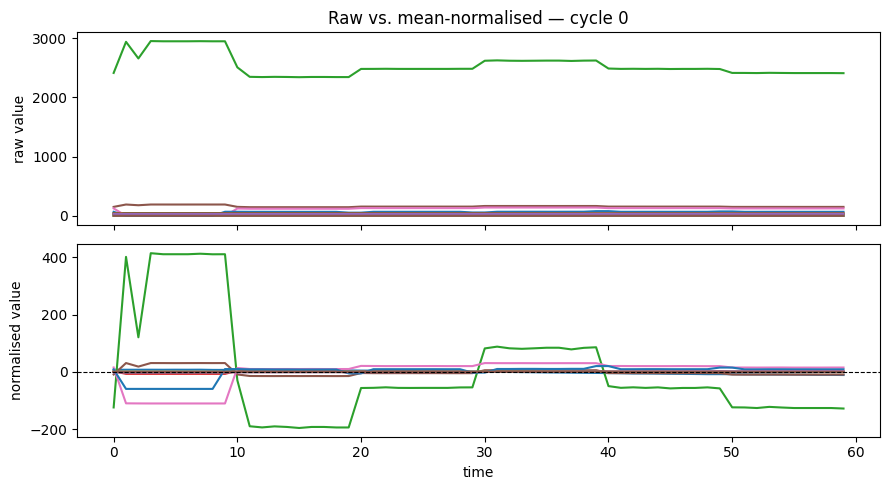

In [15]:
example_norm = normalized_cycles_data.loc[example_cycle]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
example_raw.plot(ax=axes[0], legend=False)
axes[0].set_ylabel('raw value')
axes[0].set_title(f'Raw vs. mean-normalised — cycle {example_cycle}')

example_norm.plot(ax=axes[1], legend=False)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('time')
axes[1].set_ylabel('normalised value')

plt.tight_layout()
plt.show()

## 3. Per-metric pipeline

Wrap the AVD computation, reshaping, classification, and per-metric plots into one function so we can run it for both `MAD` and `SD` without duplicating cells.

In [16]:
def run_for_metric(metric, w_size, w_incre):
    # --- 3a) AVD feature per cycle ---
    results_list = []
    cycles = normalized_cycles_data.index.get_level_values('cycle').unique()
    start = time.time()
    for cyc in cycles:
        cycle_data = normalized_cycles_data.loc[cyc]
        avd_for_cycle = calculate_AVD_feature(
            pd.DataFrame(cycle_data), metric=metric, w_size=w_size, w_incre=w_incre
        )
        for time_point, row in avd_for_cycle.iterrows():
            results_list.append((cyc, time_point) + tuple(row.values))
    print(f'AVD calc time ({metric}): {time.time() - start:.2f} s')

    columns = ['cycle', 'time', metric]
    avd_results = pd.DataFrame(results_list, columns=columns)
    avd_results.set_index(['cycle', 'time'], inplace=True)
    avd_results['class'] = avd_results.index.get_level_values('cycle').map(class_info_series)

    # --- 3b) Save and reshape into a per-cycle wide table ---
    save_dir_proc = f'output/Data_Processing_{dataset}'
    os.makedirs(save_dir_proc, exist_ok=True)
    avd_path = f'{save_dir_proc}/avd_results_{metric}_{dataset}.csv'
    avd_results.to_csv(avd_path)

    avd_reloaded = pd.read_csv(avd_path)
    pivot_df = avd_reloaded.pivot_table(index='cycle', columns='time')
    pivot_df = pivot_df.sort_index(axis=1, level=1)
    result_df = pivot_df.stack(level=0)

    class_list = class_info_series.tolist()
    for cycle in result_df.index.levels[0]:
        result_df = result_df.drop(index=(cycle, 'class'))
    result_df['class'] = class_list
    result_df.reset_index(inplace=True)
    result_df.rename(columns={'level_1': 'Metric'}, inplace=True)

    # --- Plot 1: mean AVD curve per class ---
    time_cols = [c for c in result_df.columns if c not in ('cycle', 'Metric', 'class')]
    class_mean_curves = result_df.groupby('class')[time_cols].mean()

    fig, ax = plt.subplots(figsize=(9, 3.5))
    for cls, row in class_mean_curves.iterrows():
        ax.plot(time_cols, row.values, label=str(cls))
    ax.set_xlabel('time (window end)')
    ax.set_ylabel(f'mean AVD ({metric})')
    ax.set_title(f'Mean AVD curve per class — {dataset} / {metric}')
    if class_mean_curves.shape[0] <= 12:
        ax.legend(title='class', loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- 3c) LazyPredict classification benchmark ---
    save_dir_results = f'output/Results_{dataset}'
    os.makedirs(save_dir_results, exist_ok=True)

    X = result_df.drop(['class', 'cycle', 'Metric'], axis=1)
    y = result_df['class']
    y_encoded = LabelEncoder().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )
    X_train = np.array(X_train, dtype=float)
    X_test = np.array(X_test, dtype=float)

    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    models, _ = clf.fit(X_train, X_test, y_train, y_test)

    out_path = os.path.join(save_dir_results, f'Classification_Result_{metric}.csv')
    models.to_csv(out_path)
    print(f'Classification results saved to {out_path}')

    # --- Plot 2: top-10 classifier accuracies ---
    top10 = models['Accuracy'].head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 4))
    top10.plot(kind='barh', ax=ax, color='seagreen', edgecolor='black')
    ax.set_xlabel('accuracy')
    ax.set_title(f'Top-10 classifiers by accuracy — {dataset} / {metric}')
    ax.set_xlim(0, 1)
    for i, v in enumerate(top10.values):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    return models

## 4. Run with `MAD`

Paper parameters for Hydraulic: `metric="MAD"`, `w_size=10`, `w_incre=1`.

AVD calc time (MAD): 14.43 s


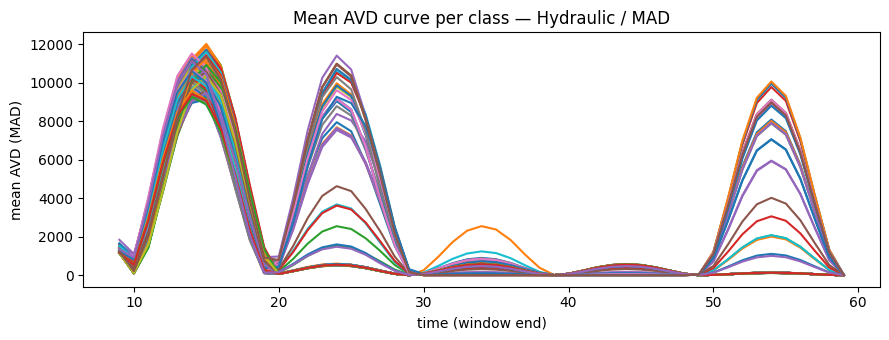

Classification results saved to output/Results_Hydraulic/Classification_Result_MAD.csv


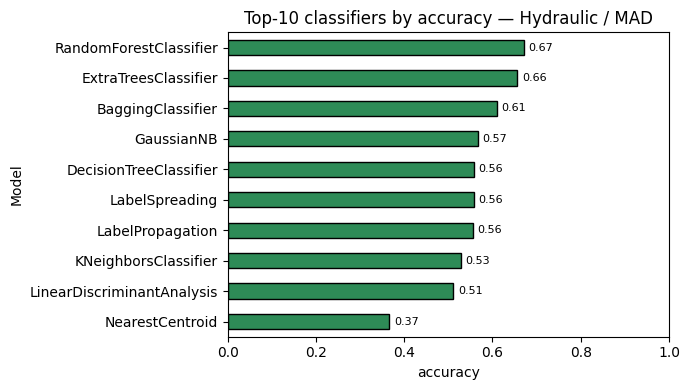

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
RandomForestClassifier,0.671756,0.588820,None,0.652036,0.707451,0.671756,2.038788
ExtraTreesClassifier,0.656489,0.559868,None,0.634736,0.706073,0.656489,0.486987
BaggingClassifier,0.609160,0.521632,None,0.591257,0.661469,0.609160,0.819498
GaussianNB,0.567939,0.487290,None,0.559413,0.621581,0.567939,0.045065
DecisionTreeClassifier,0.557252,0.463255,None,0.545780,0.584262,0.557252,0.200142
LabelSpreading,0.558779,0.445090,None,0.524545,0.547777,0.558779,1.427534
LabelPropagation,0.555725,0.441302,None,0.521403,0.543823,0.555725,0.406148
KNeighborsClassifier,0.528244,0.406740,None,0.492769,0.524107,0.528244,0.037778
LinearDiscriminantAnalysis,0.511450,0.395558,None,0.485254,0.526689,0.511450,0.175440


In [17]:
models_mad = run_for_metric('MAD', w_size, w_incre)
models_mad

## 5. Run with `SD`

Paper parameters for Hydraulic: `metric="SD"`, `w_size=10`, `w_incre=1`.

AVD calc time (SD): 14.93 s


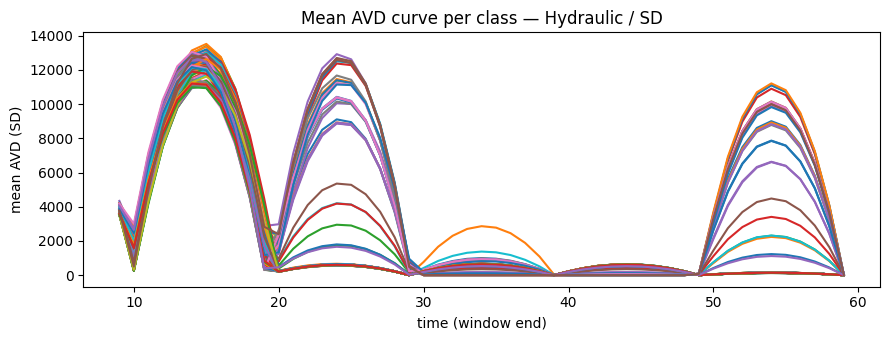

Classification results saved to output/Results_Hydraulic/Classification_Result_SD.csv


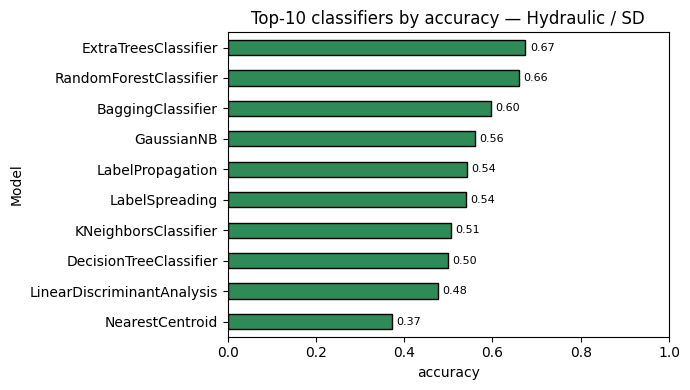

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
ExtraTreesClassifier,0.674809,0.580703,None,0.652980,0.705778,0.674809,0.503266
RandomForestClassifier,0.659542,0.568940,None,0.639740,0.685603,0.659542,1.538775
BaggingClassifier,0.596947,0.510750,None,0.583410,0.646292,0.596947,0.842180
GaussianNB,0.560305,0.480779,None,0.542053,0.589266,0.560305,0.051190
LabelPropagation,0.541985,0.417366,None,0.515140,0.546700,0.541985,0.596464
LabelSpreading,0.538931,0.413671,None,0.504235,0.520398,0.538931,1.742908
KNeighborsClassifier,0.505344,0.389594,None,0.465990,0.481607,0.505344,0.063689
DecisionTreeClassifier,0.499237,0.373733,None,0.479411,0.510538,0.499237,0.190663
LinearDiscriminantAnalysis,0.476336,0.351046,None,0.459225,0.504807,0.476336,0.211968


In [18]:
models_sd = run_for_metric('SD', w_size, w_incre)
models_sd